   well_id  avg_oil_ton  total_oil_ton  avg_downtime_ratio      name
0        1       213.15         6394.5                0.02  Well-101
1        2       185.82         5574.5                0.03  Well-102
2        3       121.70         3650.9                0.08  Well-203
3        4         0.00            0.0                1.00  Well-304
4        5       198.43         5952.9                0.02  Well-305
oil_ton           1.000000
temperature       0.880711
pressure          0.880851
downtime_hours   -0.655802
Name: oil_ton, dtype: float64


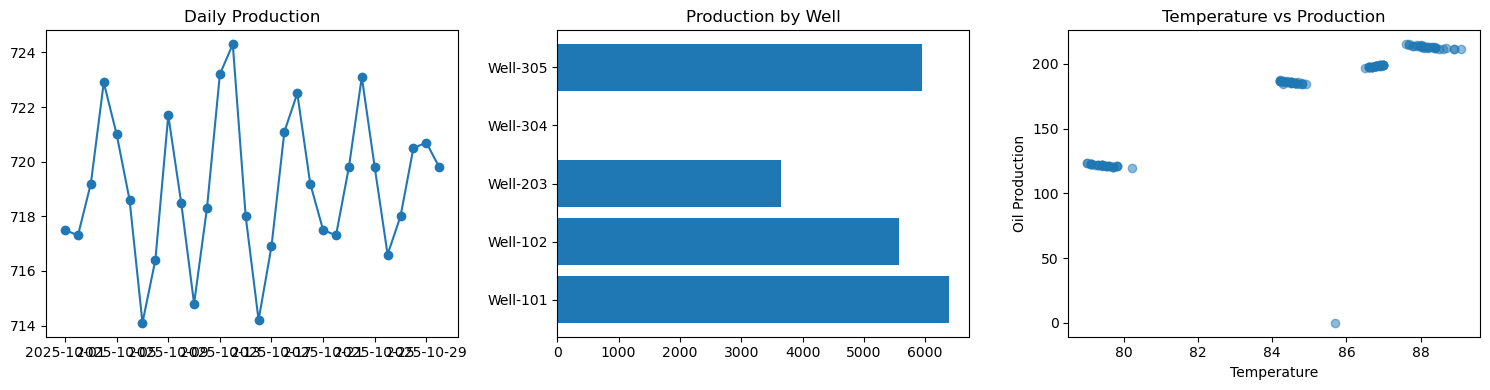

In [1]:
# 03_production_analytics.ipynb
import pandas as pd
import matplotlib.pyplot as plt
import boto3
from botocore.client import Config
import io

s3 = boto3.client('s3', endpoint_url='http://minio:9000', aws_access_key_id='minioadmin', aws_secret_access_key='minioadmin123', config=Config(signature_version='s3v4'))

def read(key):
    resp = s3.get_object(Bucket='oil-data-lake', Key=key)
    return pd.read_parquet(io.BytesIO(resp['Body'].read()))

production = read('processed/production_clean.parquet')
wells = read('raw/wells.parquet')
daily_production = read('marts/daily_production.parquet')
well_kpi = read('marts/well_kpi.parquet')

print(well_kpi)

corr = production[['oil_ton', 'temperature', 'pressure', 'downtime_hours']].corr()
print(corr['oil_ton'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(daily_production['date'], daily_production['oil_ton'], marker='o')
axes[0].set_title('Daily Production')

well_prod = production.groupby('well_id')['oil_ton'].sum().reset_index()
well_prod = well_prod.merge(wells[['well_id', 'name']], on='well_id')
axes[1].barh(well_prod['name'], well_prod['oil_ton'])
axes[1].set_title('Production by Well')

axes[2].scatter(production['temperature'], production['oil_ton'], alpha=0.5)
axes[2].set_xlabel('Temperature')
axes[2].set_ylabel('Oil Production')
axes[2].set_title('Temperature vs Production')

plt.tight_layout()
plt.savefig('production_charts.png')
plt.show()